# COCO Dataset Image Processing
This notebook processes 20,000 random images from COCO dataset:
- Resizes to 250x250
- Normalizes by dividing by 255
- Applies augmentations (flip, rotate, contrast, crop, zoom, stretch)
- Displays 20 random augmented images

In [ ]:
# Cell 1: Install Required Libraries
!pip install pycocotools
!pip install albumentations

In [ ]:
# Cell 2: Import Libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
from pycocotools.coco import COCO
import urllib.request
import zipfile
from tqdm import tqdm
import albumentations as A

In [ ]:
# Cell 3: Download COCO Dataset
# Create directories
os.makedirs('coco_dataset', exist_ok=True)
os.makedirs('coco_dataset/images', exist_ok=True)
os.makedirs('coco_dataset/annotations', exist_ok=True)

# Download train images (for 20k+ images) - this will take time!
# Use val2017 for faster testing (only ~5k images)
print("Downloading COCO train images...")
img_url = 'http://images.cocodataset.org/zips/train2017.zip'  # Change to val2017.zip for testing
img_path = 'coco_dataset/train2017.zip'

urllib.request.urlretrieve(img_url, img_path)
print("Download complete!")

# Extract images
print("Extracting images...")
with zipfile.ZipFile(img_path, 'r') as zip_ref:
    zip_ref.extractall('coco_dataset/images/')
print("Extraction complete!")

Download complete!
Extracting images...
Extraction complete!


In [ ]:
# Cell 4: Download Annotations
# Download annotations
print("Downloading annotations...")
ann_url = 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip'
ann_path = 'coco_dataset/annotations.zip'

urllib.request.urlretrieve(ann_url, ann_path)
print("Download complete!")

# Extract annotations
print("Extracting annotations...")
with zipfile.ZipFile(ann_path, 'r') as zip_ref:
    zip_ref.extractall('coco_dataset/annotations/')
print("Extraction complete!")

Download complete!
Extracting annotations...
Extraction complete!


In [ ]:
# Cell 5: Initialize COCO API
# Initialize COCO API (change to instances_val2017.json if using val dataset)
ann_file = 'coco_dataset/annotations/annotations/instances_train2017.json'
coco = COCO(ann_file)

# Get all image IDs
img_ids = coco.getImgIds()
print(f"Total images available: {len(img_ids)}")

loading annotations into memory...
Done (t=12.53s)
creating index...
index created!
Total images available: 118287


In [ ]:
# Cell 6: Select Random 20,000 Images
# Select random 20,000 images
random.seed(42)  # For reproducibility
selected_img_ids = random.sample(img_ids, min(20000, len(img_ids)))
print(f"Selected {len(selected_img_ids)} images for processing")

Selected 20000 images for processing


In [ ]:
# Cell 7: Define Augmentation Pipeline
# Define augmentation pipeline using Albumentations
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.RandomCrop(height=200, width=200, p=0.3),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2, rotate_limit=15, p=0.5),
    A.OneOf([
        A.ElasticTransform(alpha=120, sigma=120 * 0.05, p=1),
        A.GridDistortion(p=1),
        A.OpticalDistortion(distort_limit=1, shift_limit=0.5, p=1),
    ], p=0.3),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-102171721.py:13: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(distort_limit=1, shift_limit=0.5, p=1),


In [ ]:
# Cell 8: Process Images Function
def process_image(img_info, coco, target_size=(250, 250)):
    """
    Load, resize, normalize, and augment an image
    """
    # Get image path
    img_data = coco.loadImgs(img_info)[0]
    # Change train2017 to val2017 if using validation set
    img_path = f"coco_dataset/images/train2017/{img_data['file_name']}"

    # Load image
    image = cv2.imread(img_path)
    if image is None:
        return None, None

    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Resize to target size
    resized_image = cv2.resize(image, target_size, interpolation=cv2.INTER_LINEAR)

    # Normalize by dividing by 255
    normalized_image = resized_image.astype(np.float32) / 255.0

    # Apply augmentation
    augmented = transform(image=normalized_image)
    augmented_image = augmented['image']

    return normalized_image, augmented_image

In [ ]:
# Cell 9: Process Images in Batches - Memory Efficient
import gc

# We'll process images but only keep track of 20 random ones for display
# This saves memory significantly

# Select 20 random indices from our 20,000 images for final display
display_indices = sorted(random.sample(range(len(selected_img_ids)), 20))
display_images = {}

print("Processing images in batches...")
batch_size = 100
total_processed = 0
failed_count = 0

for batch_start in tqdm(range(0, len(selected_img_ids), batch_size)):
    batch_end = min(batch_start + batch_size, len(selected_img_ids))
    batch_ids = selected_img_ids[batch_start:batch_end]

    for local_idx, img_id in enumerate(batch_ids):
        global_idx = batch_start + local_idx

        # Process image
        normalized, augmented = process_image(img_id, coco)

        if normalized is not None:
            total_processed += 1

            # Only keep images we want to display (saves memory!)
            if global_idx in display_indices:
                display_images[global_idx] = augmented
        else:
            failed_count += 1

        # Stop if we've processed 20,000 images
        if total_processed >= 20000:
            break

    # Clear memory after each batch
    gc.collect()

    if total_processed >= 20000:
        break

print(f"\nSuccessfully processed {total_processed} images")
print(f"Failed to load {failed_count} images")
print(f"Kept {len(display_images)} images for display")

Processing images in batches...


100%|█████████▉| 199/200 [09:00<00:02,  2.72s/it]


Successfully processed 20000 images
Failed to load 0 images
Kept 20 images for display


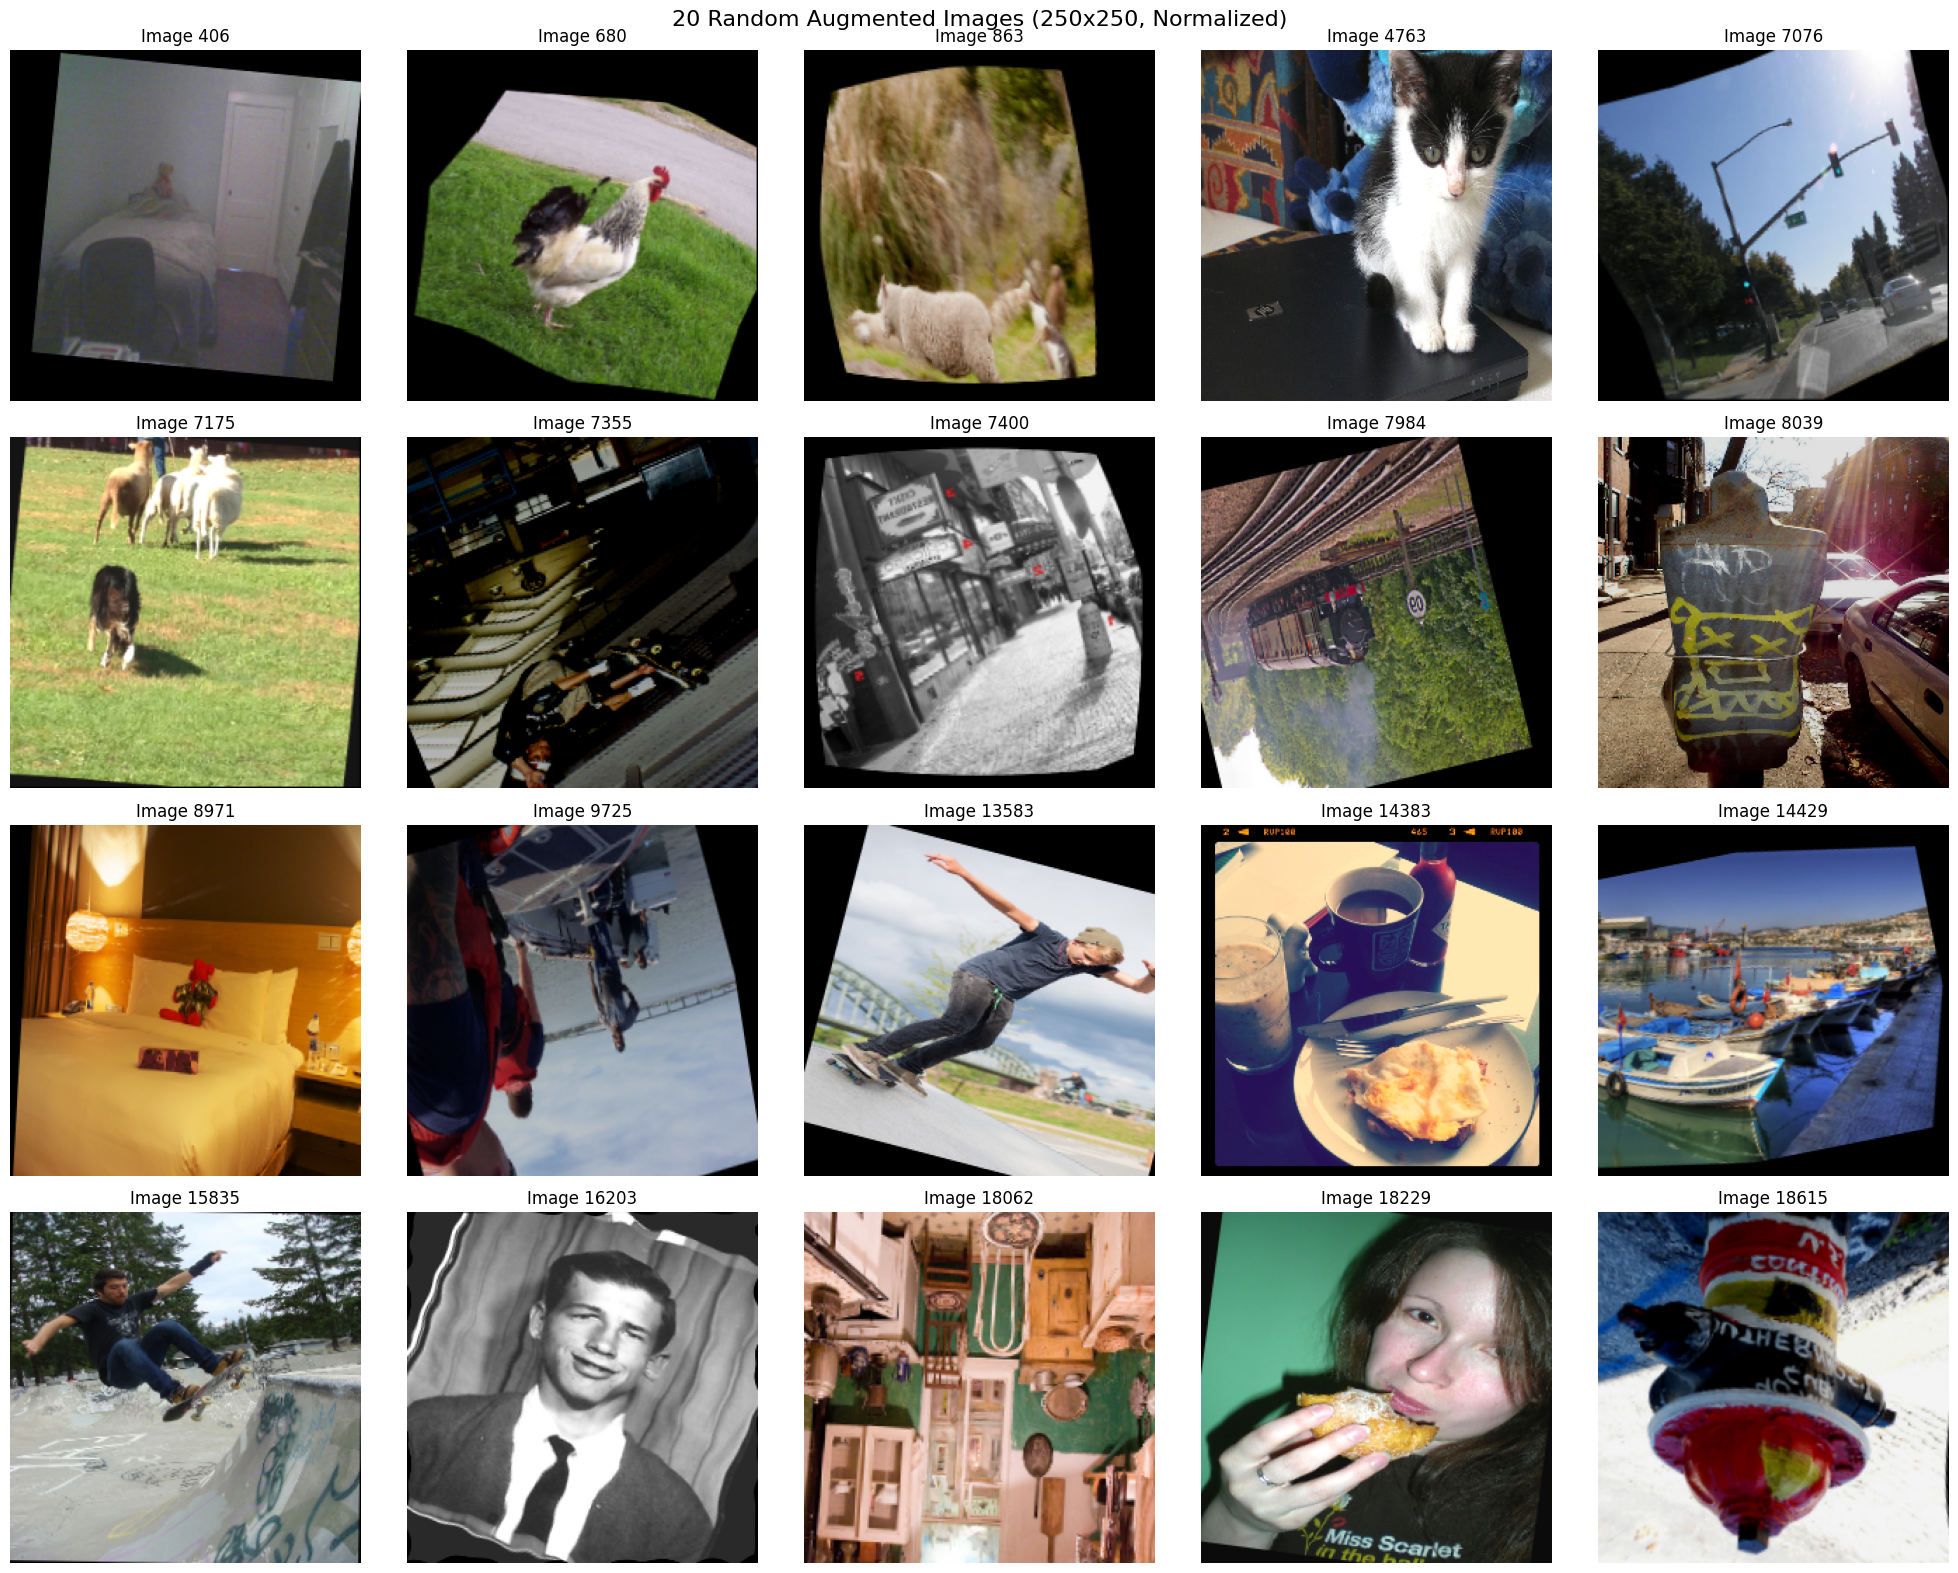

In [ ]:
# Cell 10: Display the 20 Selected Images
# Create a grid to display images
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
fig.suptitle('20 Random Augmented Images (250x250, Normalized)', fontsize=16)

# Sort the display images by their original index
sorted_display_items = sorted(display_images.items())

for idx, ax in enumerate(axes.flat):
    if idx < len(sorted_display_items):
        img_idx, img = sorted_display_items[idx]

        # Display augmented image
        ax.imshow(img)
        ax.set_title(f'Image {img_idx}')
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

Processing images for comparison...


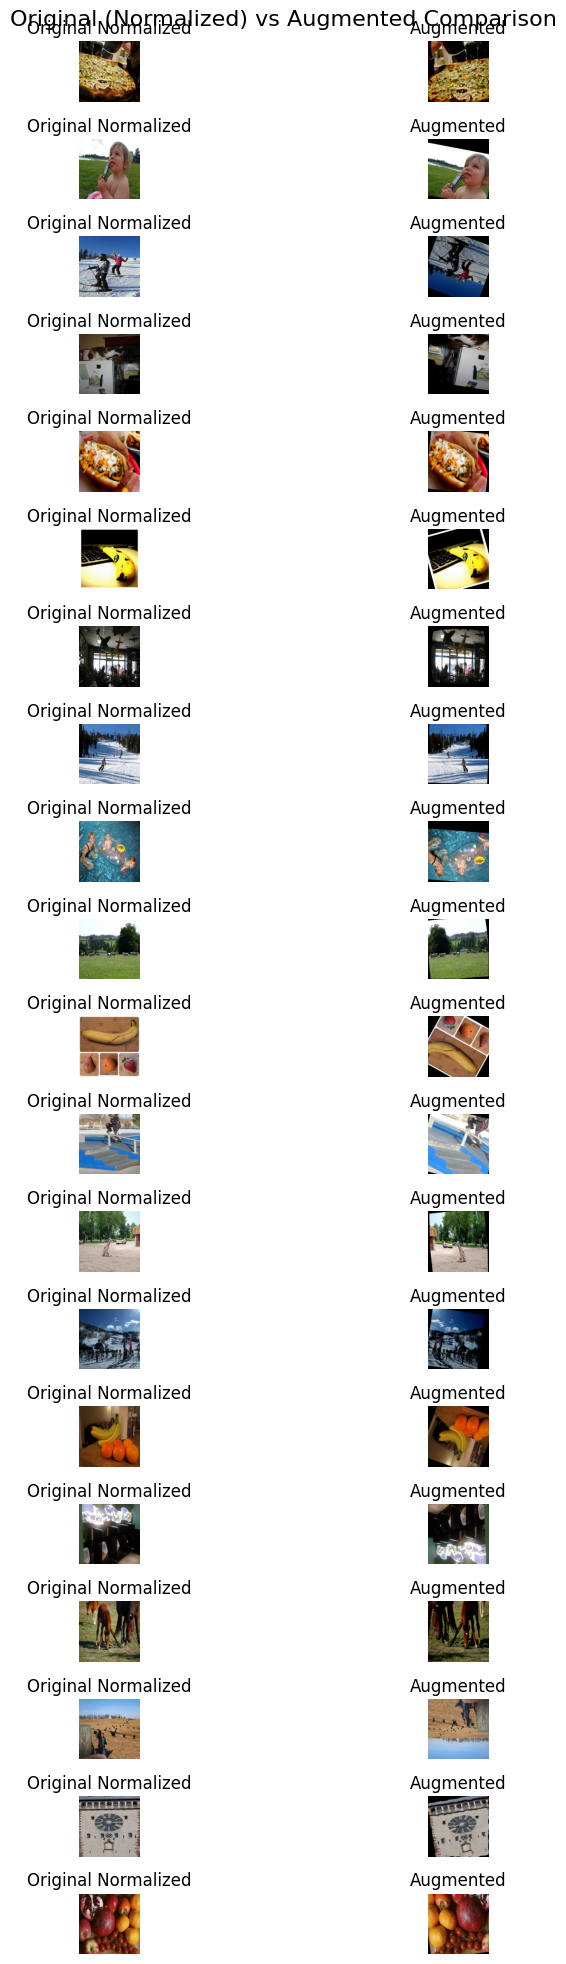

In [ ]:
# Cell 11: Compare Original vs Augmented (Updated)
# Process 5 fresh images for comparison
num_compare = 20
compare_ids = random.sample(selected_img_ids[:1000], num_compare)

fig, axes = plt.subplots(num_compare, 2, figsize=(10, 20))
fig.suptitle('Original (Normalized) vs Augmented Comparison', fontsize=16)

print("Processing images for comparison...")
for i, img_id in enumerate(compare_ids):
    normalized, augmented = process_image(img_id, coco)

    if normalized is not None:
        # Original normalized
        axes[i, 0].imshow(normalized)
        axes[i, 0].set_title(f'Original Normalized')
        axes[i, 0].axis('off')

        # Augmented
        axes[i, 1].imshow(augmented)
        axes[i, 1].set_title(f'Augmented')
        axes[i, 1].axis('off')

plt.tight_layout()
plt.show()